## Table of Contents

1. [Import Libraries](#1)<br>
2. [Layer stacking](#2)<br>
3. [Cropping raster](#3)<br>
4. [Resamping](#4)<br>   
5. [Reprjecting](#5)<br>    

    
</div>
<hr>

In [7]:
from glob import glob
import os

import rasterio as rio
from rasterio.plot import show

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


### Working with multi-band image - Landsat image
[More on Landsat 8 Surface Reflectance Product](https://docs.digitalearthafrica.org/en/latest/data_specs/Landsat_C2_SR_specs.html)

In [8]:
# go to data directory 
#os.chdir(r'D:\Dropbox (Hunter College)\data\EDS2021F\LC08')
os.chdir(r'C:\Users\Wenge\Dropbox (Hunter College)\data\EDS2022F\NYCimg\LC09\LC09_L2SP_013032_20220915_20220917_02_T1')
os.getcwd()

cwd = os.getcwd()
# Get all surface reflectance bands 
fp = glob(os.path.join(cwd,'*S*_B*.tif'))
fp

['C:\\Users\\Wenge\\Dropbox (Hunter College)\\data\\EDS2022F\\NYCimg\\LC09\\LC09_L2SP_013032_20220915_20220917_02_T1\\LC09_L2SP_013032_20220915_20220917_02_T1_SR_B1.TIF',
 'C:\\Users\\Wenge\\Dropbox (Hunter College)\\data\\EDS2022F\\NYCimg\\LC09\\LC09_L2SP_013032_20220915_20220917_02_T1\\LC09_L2SP_013032_20220915_20220917_02_T1_SR_B2.TIF',
 'C:\\Users\\Wenge\\Dropbox (Hunter College)\\data\\EDS2022F\\NYCimg\\LC09\\LC09_L2SP_013032_20220915_20220917_02_T1\\LC09_L2SP_013032_20220915_20220917_02_T1_SR_B3.TIF',
 'C:\\Users\\Wenge\\Dropbox (Hunter College)\\data\\EDS2022F\\NYCimg\\LC09\\LC09_L2SP_013032_20220915_20220917_02_T1\\LC09_L2SP_013032_20220915_20220917_02_T1_SR_B4.TIF',
 'C:\\Users\\Wenge\\Dropbox (Hunter College)\\data\\EDS2022F\\NYCimg\\LC09\\LC09_L2SP_013032_20220915_20220917_02_T1\\LC09_L2SP_013032_20220915_20220917_02_T1_SR_B5.TIF',
 'C:\\Users\\Wenge\\Dropbox (Hunter College)\\data\\EDS2022F\\NYCimg\\LC09\\LC09_L2SP_013032_20220915_20220917_02_T1\\LC09_L2SP_013032_20220915_2

## Open multispectral band Landsat image 

In [9]:
b1 = rio.open(fp[0])
b2 = rio.open(fp[1])
b3 = rio.open(fp[2])
b4 = rio.open(fp[3])
b5 = rio.open(fp[4])
b6 = rio.open(fp[5])
b7 = rio.open(fp[6])
# Check type of the variable b1
type(b1)

rasterio.io.DatasetReader

In [5]:
b5.meta

{'driver': 'GTiff',
 'dtype': 'uint16',
 'nodata': 0.0,
 'width': 7661,
 'height': 7781,
 'count': 1,
 'crs': CRS.from_epsg(32618),
 'transform': Affine(30.0, 0.0, 525885.0,
        0.0, -30.0, 4582215.0)}

In [5]:
b5.crs

CRS.from_epsg(32618)

Text(0.5, 1.0, 'Band5')

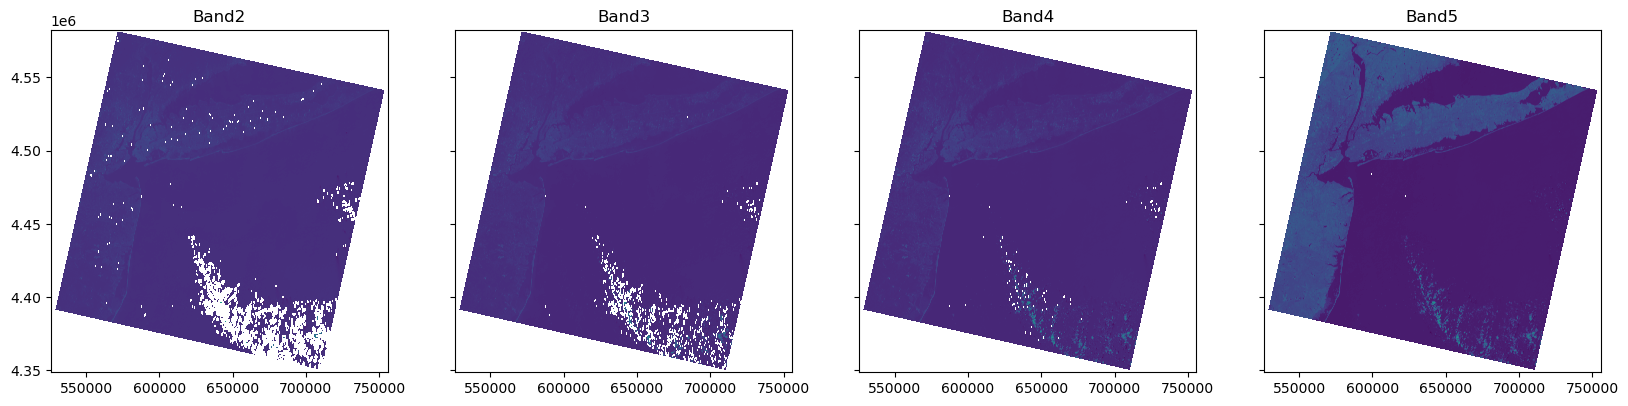

In [10]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(ncols=4, nrows=1, figsize=(20, 20), sharey=True)

# Plot 4 bands
show(b2, ax=ax1)
show(b3, ax=ax2)
show(b4, ax=ax3)
show(b5, ax=ax4)

# Add titles
ax1.set_title("Band2")
ax2.set_title("Band3")
ax3.set_title("Band4")
ax4.set_title("Band5")

C:\Users\Wenge\AppData\Local\Temp\ipykernel_18652\4063380688.py:3: RuntimeWarning: invalid value encountered in divide
  ndvi = (b5_np-b4_np)/(b5_np+b4_np)


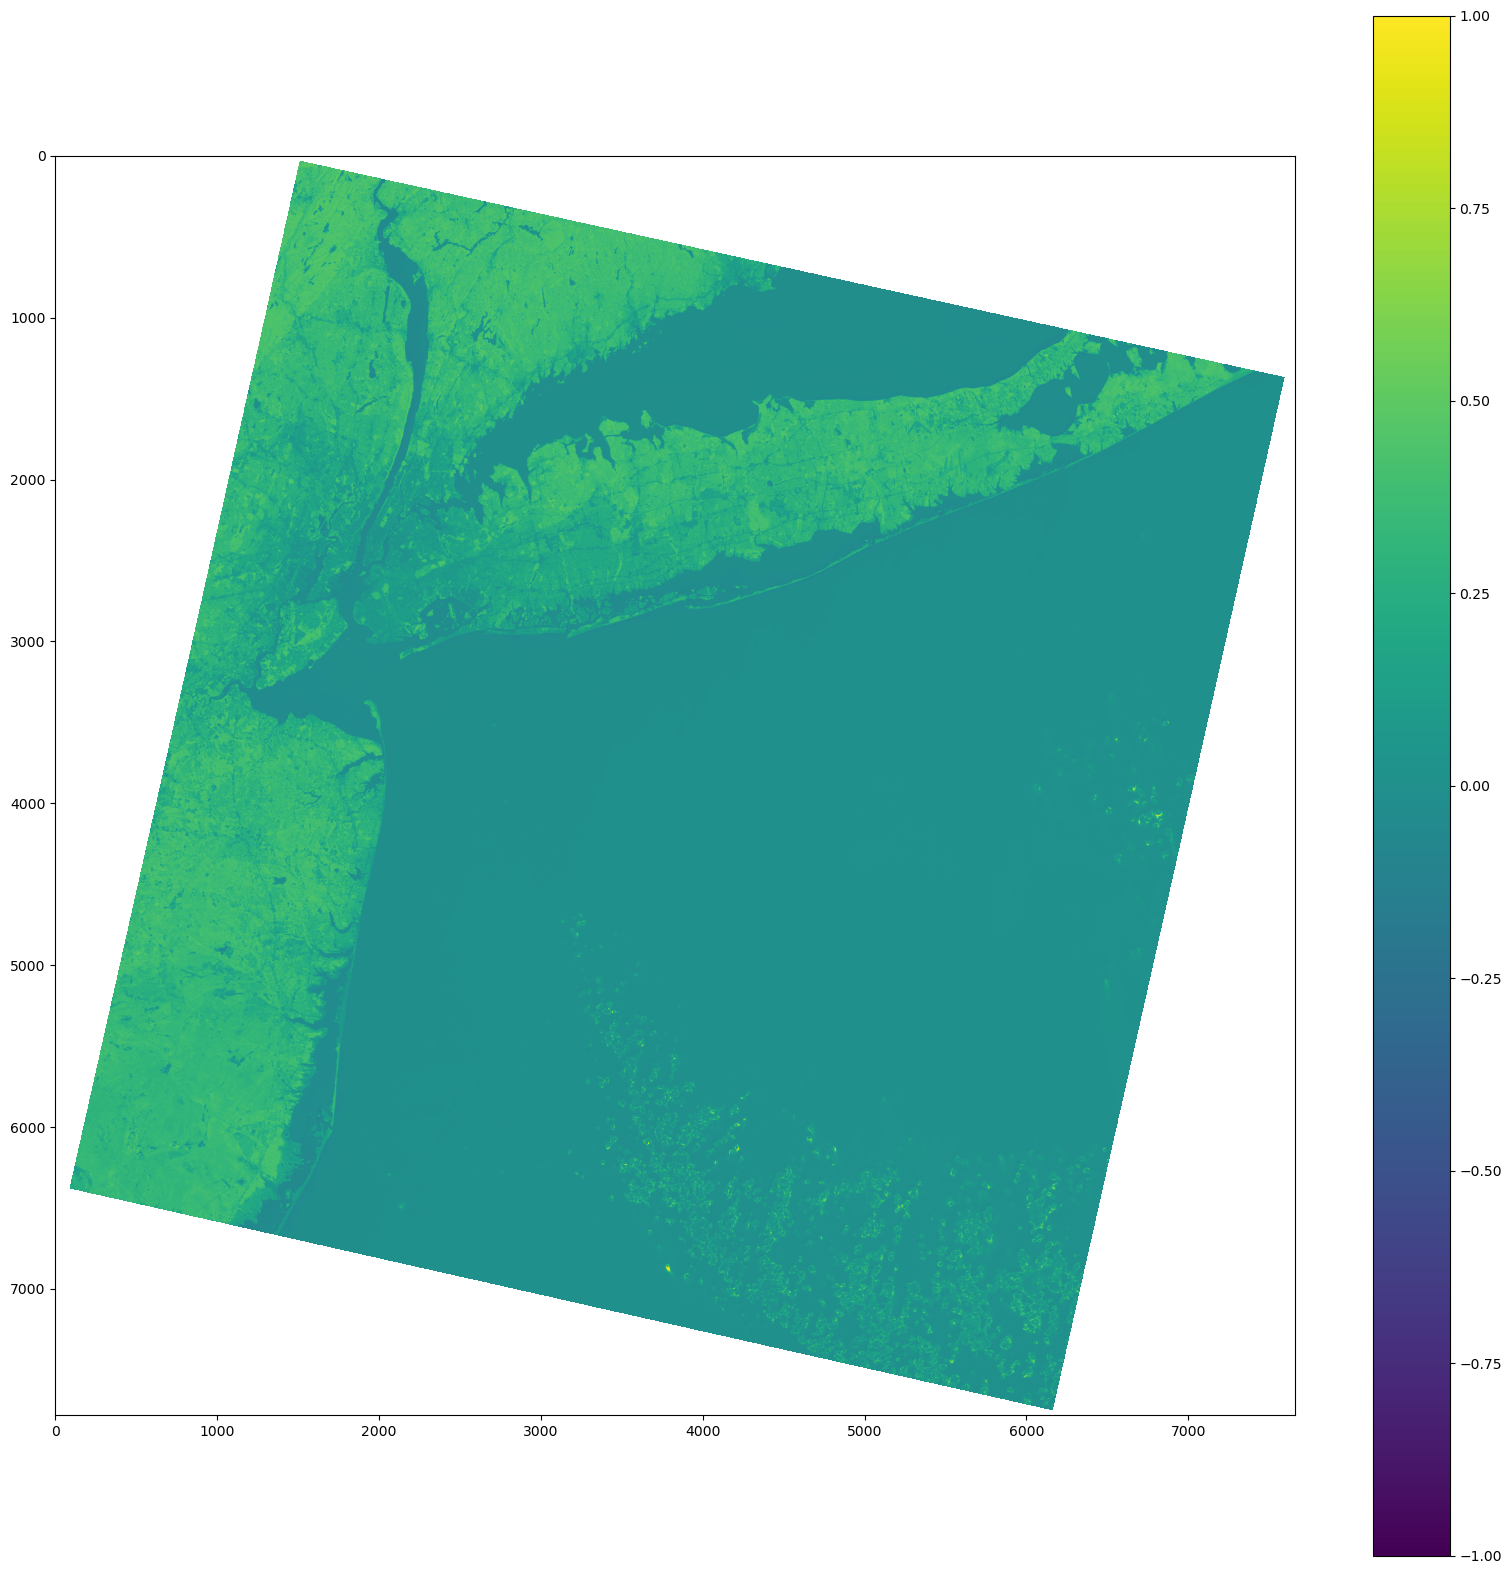

In [11]:
b5_np = b5.read(1).astype(float)/1000
b4_np = b4.read(1).astype(float)/1000
ndvi = (b5_np-b4_np)/(b5_np+b4_np)
fig = plt.subplots(figsize=(20, 20), sharey=True)
plt.imshow(ndvi)
plt.colorbar()